In [23]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END  # pyright: ignore[reportMissingImports]

In [24]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [25]:
def add(state: AgentState) -> AgentState:
    """this node add the two numbers"""

    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def sub(state: AgentState) -> AgentState:
    """this node subtract the two numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state: AgentState) -> str:
    """This node will select the next node of the graph based on the operation"""
    if state["operation"] == "+":
        return "additional Operation"
    elif state["operation"] == "-":
        return "subtract Operation"
    else:
        return "end"

In [26]:
graph = StateGraph(AgentState)

graph.add_node("add_node", add)
graph.add_node("subtrack_node", sub)
graph.add_node("router", lambda state: state) # lambda function to return the state

graph.add_edge(START, "router") 

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        # Edge to the next node based on the operation
        "additional Operation": "add_node",
        "subtract Operation": "subtrack_node",
        # "end": END
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtrack_node", END)

app = graph.compile()



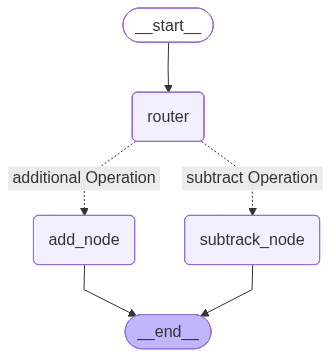

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [32]:
initial_state_1 = {"number1": 10, "number2": 5, "operation": "-"}
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}
